# Marketing Campaign Response — Extra Trees

An Extra Trees classification experiment used to investigate nonlinear structure and feature contributions. This was one of the strongest saved ROC-AUC experiments in the coursework.

> **Portfolio note:** This notebook is a curated version of completed MSc coursework. The analytical code and saved outputs come from the original work; presentation, headings, file paths and explanatory text have been cleaned for portfolio use. The dataset itself is not redistributed here.


**CONSTANTS**


In [3]:
FILE_NAME = 'data/campaign_clean.csv'


**IMPORTS**


In [80]:
import pandas as pd
import numpy as np
from IPython.display import display, HTML
import holoviews as hv
import seaborn as sns
import hvplot.pandas
import matplotlib.pyplot as plt

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import SelectFromModel, RFECV
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, precision_score, recall_score, log_loss, roc_auc_score, accuracy_score, confusion_matrix
from sklearn.inspection import permutation_importance

import shap


**OPTIONS**


# 1. Data Preprocessing


In [10]:
#upload data
df_model = pd.read_csv('./data/campaign_clean.csv')


In [11]:
df_model.head()


,Unnamed: 0,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Customer_Month,Customer_Year,Frequency,Monetary
0,0,5524,1957,Graduation,Single,58138,0,0,2012-09-04,58,635.0,88.0,546,172,88,88.0,3,8,10,4,7,False,False,False,False,False,False,3,11,True,9,2012,25,1617.0
1,1,2174,1954,Graduation,Single,46344,1,1,2014-03-08,38,11.0,1.0,6,2,1,6.0,2,1,1,2,5,False,False,False,False,False,False,3,11,False,3,2014,6,27.0
2,2,4141,1965,Graduation,Together,71613,0,0,2013-08-21,26,426.0,49.0,127,111,21,42.0,1,8,2,10,4,False,False,False,False,False,False,3,11,False,8,2013,21,776.0
3,3,6182,1984,Graduation,Together,26646,1,0,2014-02-10,26,11.0,4.0,20,10,3,5.0,2,2,0,4,6,False,False,False,False,False,False,3,11,False,2,2014,8,53.0
4,4,5324,1981,PhD,Married,58293,1,0,2014-01-19,94,173.0,43.0,118,46,27,15.0,5,5,3,6,5,False,False,False,False,False,False,3,11,False,1,2014,19,422.0


In [12]:
#Drop rows where `Marital_Status` is `YOLO` or `Absurd`
df_model = df_model.loc[~df_model['Marital_Status'].isin(['YOLO', 'Absurd'])]

#Reassign Alone to Single
df_model.loc[df_model['Marital_Status']=='Alone', 'Marital_Status'] = 'Single'

#Drop Alone
if isinstance(df_model['Marital_Status'].dtype, pd.CategoricalDtype):
    df_model['Marital_Status'] = (
        df_model['Marital_Status']
            .cat.remove_unusused_categories()
    )

df_model['Marital_Status'].value_counts()


Marital_Status
Married     836
Together    560
Single      457
Divorced    228
Widow        73
Name: count, dtype: int64

#### Feature Engineering


In [14]:
df_model.info()


<class 'pandas.core.frame.DataFrame'>
Index: 2154 entries, 0 to 2153
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           2154 non-null   int64  
 1   ID                   2154 non-null   int64  
 2   Year_Birth           2154 non-null   int64  
 3   Education            2154 non-null   object 
 4   Marital_Status       2154 non-null   object 
 5   Income               2154 non-null   int64  
 6   Kidhome              2154 non-null   int64  
 7   Teenhome             2154 non-null   int64  
 8   Dt_Customer          2154 non-null   object 
 9   Recency              2154 non-null   int64  
 10  MntWines             2154 non-null   float64
 11  MntFruits            2154 non-null   float64
 12  MntMeatProducts      2154 non-null   int64  
 13  MntFishProducts      2154 non-null   int64  
 14  MntSweetProducts     2154 non-null   int64  
 15  MntGoldProds         2154 non-null   float6

In [15]:
#Aggregate data by customer for RFM analysis (Recency, Frequency, Monetary Value)
# Compute Frequency 
df_model['Frequency'] = (
    df_model[['NumDealsPurchases',
             'NumWebPurchases',
             'NumCatalogPurchases',
             'NumStorePurchases']]
    .sum(axis=1)
)

# Compute Monetary
df_model['Monetary'] = (
    df_model[['MntWines',
             'MntFruits',
             'MntMeatProducts',
             'MntFishProducts',
             'MntSweetProducts',
             'MntGoldProds']]
    .sum(axis=1)
)

#Bucket into quartiles
df_model['R_Score'] = pd.qcut(df_model['Recency'], 4, labels=[4,3,2,1])  #in the case of recency, lower is better than higher, unlike the others
df_model['F_Score'] = pd.qcut(df_model['Frequency'], 4, labels=[1,2,3,4])
df_model['M_Score'] = pd.qcut(df_model['Monetary'], 4, labels=[1,2,3,4])


In [16]:
# find age using Year_Birth
df_model['Age'] = ((pd.to_datetime('today') -
                    pd.to_datetime(df_model['Year_Birth'], format='%Y')).dt.days // 365)
df_model = df_model.drop(columns=['Year_Birth'])


In [17]:
#drop all other columns that are irrelevant
df_model = df_model.drop(columns=['Z_CostContact', 'Z_Revenue', 'Customer_Month', 'Customer_Year'])


In [75]:
df_model.info()


<class 'pandas.core.frame.DataFrame'>
Index: 2154 entries, 0 to 2153
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Unnamed: 0           2154 non-null   int64   
 1   ID                   2154 non-null   int64   
 2   Education            2154 non-null   object  
 3   Marital_Status       2154 non-null   object  
 4   Income               2154 non-null   int64   
 5   Kidhome              2154 non-null   int64   
 6   Teenhome             2154 non-null   int64   
 7   Dt_Customer          2154 non-null   object  
 8   Recency              2154 non-null   int64   
 9   MntWines             2154 non-null   float64 
 10  MntFruits            2154 non-null   float64 
 11  MntMeatProducts      2154 non-null   int64   
 12  MntFishProducts      2154 non-null   int64   
 13  MntSweetProducts     2154 non-null   int64   
 14  MntGoldProds         2154 non-null   float64 
 15  NumDealsPurchases    2154 

/var/folders/g0/990px7q94zg1mm5vxhtzn72h0000gn/T/ipykernel_89674/1185135803.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rates = df.groupby(f'{col}_bin')['Response'].mean().reset_index()
/var/folders/g0/990px7q94zg1mm5vxhtzn72h0000gn/T/ipykernel_89674/1185135803.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rates = df.groupby(f'{col}_bin')['Response'].mean().reset_index()
/var/folders/g0/990px7q94zg1mm5vxhtzn72h0000gn/T/ipykernel_89674/1185135803.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to re

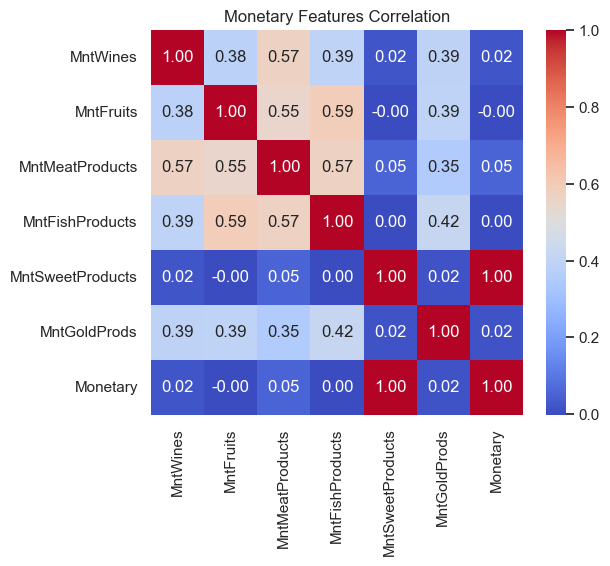

ValueError: could not convert string to float: 'Graduation'

In [84]:
# ---- Assumes you’ve already loaded df_model and cleaned it ----
df = df_model.copy()
df['Response'] = df['Response'].astype(int)

monetary_cols = [
    'MntWines','MntFruits','MntMeatProducts',
    'MntFishProducts','MntSweetProducts','MntGoldProds'
]
accepted_cols = [
    'AcceptedCmp1','AcceptedCmp2','AcceptedCmp3',
    'AcceptedCmp4','AcceptedCmp5'
]

# 1. Response rate by monetary decile
bin_results = []
for col in monetary_cols:
    df[f'{col}_bin'] = pd.qcut(df[col], q=10, duplicates='drop')
    rates = df.groupby(f'{col}_bin')['Response'].mean().reset_index()
    rates.columns = ['Bin', 'ResponseRate']
    rates['Feature'] = col
    bin_results.append(rates)
bin_df = pd.concat(bin_results)
# Display in notebook
bin_df

# 2. Response rate by accepted flag
flag_results = []
for col in accepted_cols:
    rates = df.groupby(col)['Response'].mean().reset_index()
    rates.columns = [col, 'ResponseRate']
    rates['Feature'] = col
    flag_results.append(rates)
flag_df = pd.concat(flag_results)
flag_df

# 3. Correlation with target
corr_target = df[monetary_cols + accepted_cols].corrwith(df['Response'])\
                 .sort_values(ascending=False)\
                 .reset_index()
corr_target.columns = ['Feature', 'CorrelationWithResponse']
corr_target

# 4. Correlation matrix among spend features
feature_corr = df[monetary_cols + ['Monetary']].corr()
plt.figure(figsize=(6,5))
plt.title("Monetary Features Correlation")
sns.heatmap(feature_corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

# 5. Tree-based importances
X = df.drop(columns=['Response'])
y = df['Response']
model = ExtraTreesClassifier(random_state=42, class_weight='balanced', n_estimators=100)
model.fit(X, y)
importances = pd.Series(model.feature_importances_, index=X.columns)\
                .sort_values(ascending=False).reset_index()
importances.columns = ['Feature','Importance']
importances

# 6. Permutation importance
perm = permutation_importance(model, X, y, n_repeats=10, random_state=42, n_jobs=-1)
perm_df = pd.Series(perm.importances_mean, index=X.columns)\
           .sort_values(ascending=False).reset_index()
perm_df.columns = ['Feature','PermutationImportance']
perm_df

# 7. RFECV
rfecv = RFECV(estimator=model, step=1, cv=StratifiedKFold(5),
              scoring='roc_auc', n_jobs=-1)
rfecv.fit(X, y)
plt.figure(figsize=(8,4))
plt.plot(range(1, len(rfecv.grid_scores_)+1),
         rfecv.grid_scores_, marker='o')
plt.xlabel('Number of Features Selected')
plt.ylabel('Cross-Validated AUC')
plt.title('RFECV: AUC vs. # Features')
plt.show()

# 8. SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)
shap.summary_plot(shap_values[1], X, plot_type='bar')
shap.summary_plot(shap_values[1], X)


# 2. Modeling - Extra Trees


In [57]:
X = df_model.drop([    
    'Unnamed: 0', 
    'ID', 
    'Dt_Customer',
    'Response'], 
    axis='columns'
) 

y = df_model['Response'] #target


In [59]:
# Split existing training pool into Train-sub (80% of train) and Calibration (20% of train)
X_train_sub, X_calib, y_train_sub, y_calib = train_test_split(
    X_train, y_train,
    test_size=0.20,         # 20% -> calibration
    stratify=y_train,
    random_state=42
)


In [61]:
print("X_train columns:", X_train_sub.columns.tolist())


X_train columns: ['Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'Age']


## Attempt 2: For this model, we will include all the variables and allow the model to use L1 regularization to select the variables.


In [64]:
# Expanding the feature sets to include more of the variables from the dataset
full_numeric_cols = [
    'Age', 
    'Income', 
    'Recency', 
    'Frequency', 
    'Monetary', 
    'NumWebVisitsMonth',
    'MntWines', 
    'MntFruits', 
    'MntMeatProducts', 
    'MntFishProducts', 
    'MntSweetProducts', 
    'MntGoldProds',
    'NumDealsPurchases', 
    'NumWebPurchases', 
    'NumCatalogPurchases', 
    'NumStorePurchases',
    'R_Score',
    'F_Score',
    'M_Score'
]

full_categorical_cols = [
    'Education', 
    'Marital_Status', 
    'Kidhome', 
    'Teenhome'
]

bool_cols = [
    'AcceptedCmp1', 
    'AcceptedCmp2', 
    'AcceptedCmp3', 
    'AcceptedCmp4', 
    'AcceptedCmp5', 
    'Complain'
]


In [66]:
preprocessor = ColumnTransformer ([
    ('num', StandardScaler(), full_numeric_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), full_categorical_cols),
    ('bool', 'passthrough', bool_cols)
], remainder='drop')


In [68]:
# define the model without hyperparameters
extra_trees = ExtraTreesClassifier(random_state=42, class_weight='balanced')

#define pipeline with preprocessing and model
pipeline = Pipeline([
    ("preproc",  preprocessor),
    ("clf", extra_trees)
])

# define the parameter grid for gridsearch cv
param_grid = {
    'clf__n_estimators': [20, 30, 50, 100, 200],
    'clf__max_depth': [None, 5, 12, 15, 20, 30],
    'clf__min_samples_split': [5, 10, 15, 20],
    'clf__max_features': ['sqrt', 'log2'],
}

# define CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# define scoring
scoring = {
    'roc_auc': 'roc_auc',
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'accuracy': make_scorer(accuracy_score),
    'log_loss': make_scorer(log_loss, needs_proba=True)
}

# set up GS with CV
gs = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

gs.fit(X_train, y_train)

# Print the best hyperparameters found by GridSearchCV
print("Best Hyperparameters found by GridSearchCV:", gs.best_params_)

# Use the best estimator from GridSearchCV
best_model = gs.best_estimator_

# define scoring
scoring = {
    'roc_auc': 'roc_auc',
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'accuracy': make_scorer(accuracy_score),
    'log_loss': make_scorer(log_loss, needs_proba=True)
}

cv_results = cross_validate(
    pipeline, 
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    error_score='raise'
)

# print per-fold results on the training data
print(' Fold |  AUC  |  Prec. | Recall | Accuracy | Log-Loss')
print('------+-------+--------+--------+----------+---------')
for i in range(len(cv_results['test_roc_auc'])):
    auc = cv_results['test_roc_auc'][i]
    prec = cv_results['test_precision'][i]
    rec = cv_results['test_recall'][i]
    acu = cv_results['test_accuracy'][i]
    loss = cv_results['test_log_loss'][i]
    print(f' {i+1:>2d}   |{auc:6.3f} | {prec:6.3f} | {rec:6.3f} | {acu:6.3f}   |{loss:8.3f}')

# Calculate and print the mean and standard deviation of the metrics
mean_auc = np.mean(cv_results['test_roc_auc'])
std_auc = np.std(cv_results['test_roc_auc'])

mean_prec = np.mean(cv_results['test_precision'])
std_prec = np.std(cv_results['test_precision'])

mean_rec = np.mean(cv_results['test_recall'])
std_rec = np.std(cv_results['test_recall'])

mean_acu = np.mean(cv_results['test_accuracy'])
std_acu = np.std(cv_results['test_accuracy'])

mean_loss = np.mean(cv_results['test_log_loss'])
std_loss = np.std(cv_results['test_log_loss'])

# Print total scores (mean and std)
print('\nTotal (Mean ± Std) Scores:')
print(f'AUC: {mean_auc:6.3f} ± {std_auc:6.3f}')
print(f'Precision: {mean_prec:6.3f} ± {std_prec:6.3f}')
print(f'Recall: {mean_rec:6.3f} ± {std_rec:6.3f}')
print(f'Accuracy: {mean_acu:6.3f} ± {std_acu:6.3f}')
print(f'Log-Loss: {mean_loss:6.3f} ± {std_loss:6.3f}')


Fitting 5 folds for each of 240 candidates, totalling 1200 fits


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_scorer.py:548: FutureWarning: The `needs_threshold` and `needs_proba` parameter are deprecated in version 1.4 and will be removed in 1.6. You can either let `response_method` be `None` or set it to `predict` to preserve the same behaviour.
  warnings.warn(


Best Hyperparameters found by GridSearchCV: {'clf__max_depth': 15, 'clf__max_features': 'log2', 'clf__min_samples_split': 10, 'clf__n_estimators': 200}


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_scorer.py:548: FutureWarning: The `needs_threshold` and `needs_proba` parameter are deprecated in version 1.4 and will be removed in 1.6. You can either let `response_method` be `None` or set it to `predict` to preserve the same behaviour.
  warnings.warn(


 Fold |  AUC  |  Prec. | Recall | Accuracy | Log-Loss
------+-------+--------+--------+----------+---------
  1   | 0.868 |  0.750 |  0.404 |  0.890   |   0.756
  2   | 0.842 |  0.655 |  0.365 |  0.875   |   0.798
  3   | 0.863 |  0.690 |  0.385 |  0.881   |   0.686
  4   | 0.777 |  0.476 |  0.196 |  0.849   |   1.214
  5   | 0.852 |  0.700 |  0.269 |  0.872   |   0.665

Total (Mean ± Std) Scores:
AUC:  0.840 ±  0.033
Precision:  0.654 ±  0.094
Recall:  0.324 ±  0.079
Accuracy:  0.873 ±  0.014
Log-Loss:  0.824 ±  0.201


In [69]:
# Get the predicted probabilities for the positive class (class 1)
proba = best_model.predict_proba(X_test)[:, 1]

# Set threshold (e.g., change threshold from 0.5 to 0.3)
threshold = 0.3  # Use 0.3 as the threshold
predictions = (proba >= threshold).astype(int)  # Adjust the threshold for classification

# Print min and max probabilities
print(f"Min Probability: {proba.min()}")
print(f"Max Probability: {proba.max()}")

# Evaluate the model using the adjusted predictions
print("Hold-out ROC AUC:  ", roc_auc_score(y_test, proba).round(3))  # AUC uses probabilities
print("Hold-out Precision:", precision_score(y_test, predictions).round(3))  # Use adjusted predictions
print("Hold-out Recall:   ", recall_score(y_test, predictions).round(3))  # Use adjusted predictions
print("Hold-out Accuracy: ", round(accuracy_score(y_test, predictions), 3))  # Use adjusted predictions
print("Hold-out Log-Loss: ", round(log_loss(y_test, proba), 3))  # Log-Loss uses probabilities


Min Probability: 0.005504133856721517
Max Probability: 0.9382794067763304
Hold-out ROC AUC:   0.904
Hold-out Precision: 0.41
Hold-out Recall:    0.877
Hold-out Accuracy:  0.791
Hold-out Log-Loss:  0.312


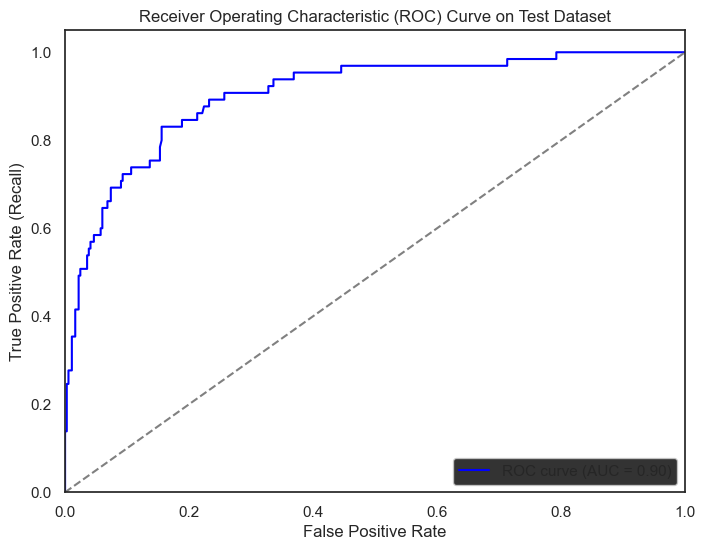

In [70]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get the predicted probabilities
y_pred_proba = best_model.predict_proba(X_test)[:, 1]  # Probabilities for class 1

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line (random model)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve on Test Dataset')
plt.legend(loc='lower right')
plt.show()


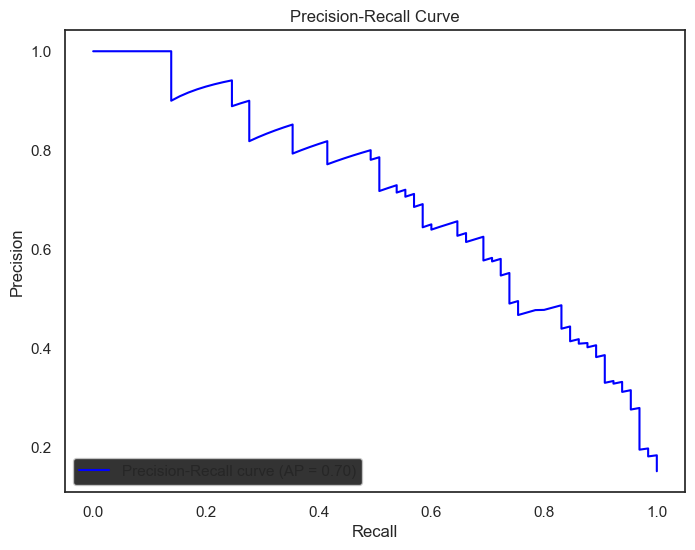

In [71]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Compute Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
avg_precision = average_precision_score(y_test, y_pred_proba)

# Plot the Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', label=f'Precision-Recall curve (AP = {avg_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.show()


▶ Optimal threshold = 0.46 → Profit €270.0
  Precision @ 0.46 = 60.00%
  Recall    @ 0.46 = 69.23%


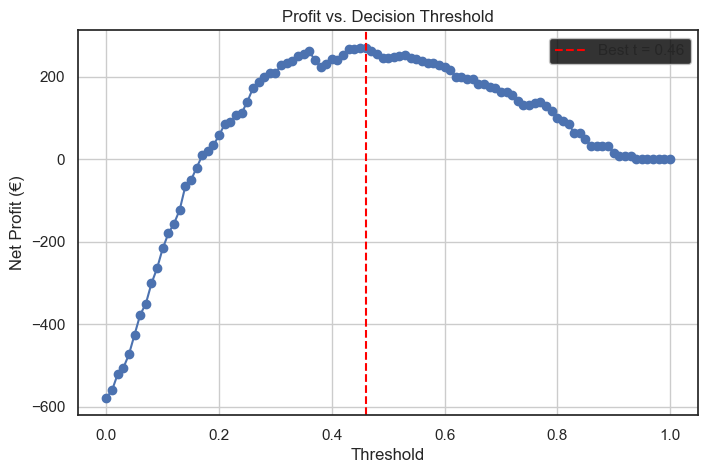

In [72]:
# 1. Build a grid of thresholds
thresholds = np.linspace(0.0, 1.0, 101)

# 2. For each threshold, compute TP, FP, precision, recall, and profit
records = []
for t in thresholds:
    # apply threshold
    preds_t = (proba >= t).astype(int)

    # confusion matrix: tn, fp, fn, tp
    tn, fp, fn, tp = confusion_matrix(y_test, preds_t).ravel()

    # compute precision/recall if you want
    precision_t = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall_t    = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    # compute profit: +8€ per TP, –3€ per FP
    profit_t = 8 * tp - 3 * fp

    records.append({
        'threshold':    t,
        'TP':           tp,
        'FP':           fp,
        'precision':    precision_t,
        'recall':       recall_t,
        'profit':       profit_t
    })

df_thresh = pd.DataFrame(records)

# 3. Find your optimal threshold
best_idx      = df_thresh['profit'].idxmax()
best_row      = df_thresh.loc[best_idx]
best_thr      = best_row['threshold']
best_profit   = best_row['profit']
best_precision= best_row['precision']
best_recall   = best_row['recall']

print(f"▶ Optimal threshold = {best_thr:.2f} → Profit €{best_profit}")
print(f"  Precision @ {best_thr:.2f} = {best_precision:.2%}")
print(f"  Recall    @ {best_thr:.2f} = {best_recall:.2%}")

# 4. Plot Profit vs Threshold
plt.figure(figsize=(8,5))
plt.plot(df_thresh['threshold'], df_thresh['profit'], marker='o', linestyle='-')
plt.axvline(best_thr, color='red', linestyle='--',
            label=f"Best t = {best_thr:.2f}")
plt.xlabel('Threshold')
plt.ylabel('Net Profit (€)')
plt.title('Profit vs. Decision Threshold')
plt.legend()
plt.grid(True)
plt.show()


In [73]:
confusion_matrix(y_test, y_pred_proba)


ValueError: Classification metrics can't handle a mix of binary and continuous targets